## Fråga 12

### Försök förbättra Random Forest-modellen för huspriser i Kalifornien

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [29]:
housing = pd.read_csv(
    "./chapter_02_ml_project/data/housing.csv"
)

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [30]:
# Liten EDA

housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


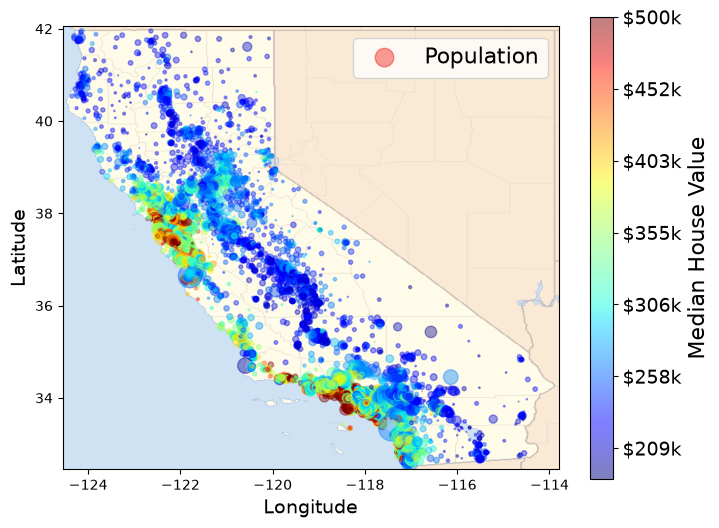

In [31]:
# Importerar bild för att visualisera bättre

import matplotlib.image as mpimg

california_img = mpimg.imread(
    "./chapter_02_ml_project/img_2/california.png"
)

ax = train.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    figsize=(8, 6),
    s=train["population"] / 100,
    label="Population",
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=False,
    alpha=0.4
)

plt.imshow(
    california_img,
    extent=[-124.55, -113.80, 32.45, 42.05],
    alpha=0.5,
    cmap=plt.get_cmap("jet")
)

plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = train["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)

cbar = plt.colorbar(ticks=tick_values / prices.max())
cbar.ax.set_yticklabels(
    [f"${v/1000:.0f}k" for v in tick_values],
    fontsize=14
)

cbar.set_label("Median House Value", fontsize=16)

plt.legend(fontsize=16)

In [32]:
# Vi tar bort ocean_proximity som exempelkoden i boken. Dock är detta nominal data som har stark korrelation med huspriserna. One hot encoding?

data = housing.drop(columns=["ocean_proximity"])

X = data.drop(columns=["median_house_value"])
y = data["median_house_value"]

In [33]:
# Delar upp i träning och test data

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=40
)

# Delar sedan upp i valideringsdata. 

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.3,
    random_state=36
)

In [34]:
# Vi hanterar saknade värden
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)

In [35]:
# Startpunken, vi kör vår random forest på träningsdatan och räknar ut RMSE

baseline_rf = RandomForestRegressor(
    random_state=42
)

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_val)

baseline_rmse = root_mean_squared_error(
    y_val,
    baseline_pred
)

print("Baseline Random Forest RMSE:", baseline_rmse)

Baseline Random Forest RMSE: 50124.76646705056


In [36]:
# Vi lägger in några hyperparametrar
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Kör en gridsearch för att hitta bästa, neg RMSE som scoring system
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV RMSE: 51537.391175461125


In [37]:
best_rf = grid_search.best_estimator_

y_val_pred = best_rf.predict(X_val)

tuned_rmse = root_mean_squared_error(
    y_val,
    y_val_pred
)

print("Tuned Random Forest RMSE:", tuned_rmse)

Tuned Random Forest RMSE: 49809.3637406764


Första gången vi körde modellen fick vi ett RMSE på cirka `50125`, vilket redan var bättre än resultatet i kursens exempel på cirka `52278`.

Efter hyperparameter-tuning med `GridSearchCV` förbättrades resultatet till ca `49809` RMSE på valideringsdatan.

De bästa parametrarna blev:

- `max_depth=20`
- `min_samples_leaf=2`
- `min_samples_split=2`
- `n_estimators=300`

Hyperparameter-tuningen gav alltså en mindre men tydlig förbättring jämfört med baseline-modellen.